# Terrain Engine

## Purpose

The Terrain Engine retrieves Digital Elevation Model (DEM) data for the selected Area of Interest (AOI) and derives terrain characteristics required for Earth Intelligence analyses.

Version 1 generates:

- Elevation
- Slope
- Aspect
- Hillshade

The resulting Terrain Product serves as a reusable input for downstream modules including environmental analysis, flood modelling, infrastructure planning, and risk assessment.

# Import Libraries

## Purpose

Import the libraries required for terrain data retrieval, raster processing, and terrain analysis.

In [33]:
from pathlib import Path
import json

import geopandas as gpd
import numpy as np
import xarray as xr
import rioxarray

import planetary_computer
from pystac_client import Client
from odc.stac import load

import matplotlib.pyplot as plt

# Load Inputs

## Purpose

Load the input datasets required by the Terrain Engine.

The Terrain Engine uses:

- Area of Interest (AOI)
- Earth Intelligence Catalog

These datasets are generated by previous notebooks and provide the spatial boundary and terrain dataset information needed for terrain analysis.

In [34]:
from pathlib import Path
import json
import geopandas as gpd

DATA_DIR = Path(
    "/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Earth-Intelligence-System/data/outputs"
)

# Load Area of Interest
aoi_file = DATA_DIR / "aoi.geojson"

if not aoi_file.exists():
    raise FileNotFoundError(
        "AOI not found. Run Notebook 01 first."
    )

aoi_boundary = gpd.read_file(aoi_file)

# Load Earth Intelligence Catalog
catalog_file = DATA_DIR / "catalog.json"

if not catalog_file.exists():
    raise FileNotFoundError(
        "Catalog not found. Run Notebook 02 first."
    )

with open(catalog_file, "r", encoding="utf-8") as file:
    catalog = json.load(file)

print("Inputs loaded successfully.")

print(f"AOI Features : {len(aoi_boundary)}")
print(f"Datasets     : {len(catalog['datasets'])}")

Inputs loaded successfully.
AOI Features : 1
Datasets     : 7


# Terrain Dataset Selection

## Purpose

Select the preferred terrain dataset from the Earth Intelligence Catalog.

The selection is based on the dataset metadata rather than hardcoded dataset names.

Selection Criteria

- Category = Terrain
- Applicable = True
- Highest Priority

The selected dataset becomes the source for terrain retrieval.

In [35]:
terrain_datasets = [

    dataset

    for dataset in catalog["datasets"]

    if dataset["category"] == "Terrain"
    and dataset["applicable"]

]

if len(terrain_datasets) == 0:

    raise ValueError(
        "No applicable terrain datasets found."
    )

priority_order = {
    "Primary": 1,
    "Secondary": 2
}

terrain_datasets = sorted(

    terrain_datasets,

    key=lambda dataset: priority_order.get(
        dataset["priority"],
        99
    )

)

selected_dataset = terrain_datasets[0]

selected_dataset

{'id': 'copernicus_dem',
 'name': 'Copernicus DEM',
 'category': 'Terrain',
 'provider': 'Copernicus',
 'access_method': 'STAC',
 'stac_collection': 'cop-dem-glo-30',
 'description': 'Global Digital Elevation Model (DEM).',
 'coverage': 'Global',
 'spatial_resolution': '30 m',
 'temporal_resolution': 'Static',
 'data_type': 'Raster',
 'applicable': True,
 'priority': 'Primary',
 'notes': 'Preferred elevation dataset.'}

# Load Digital Elevation Model (DEM)

## Purpose

Retrieve the Digital Elevation Model (DEM) for the selected Area of Interest (AOI).

The DEM is loaded from the selected terrain dataset and clipped to the AOI.

The resulting elevation dataset serves as the foundation for terrain derivative generation.

In [36]:
catalog_client = Client.open(

    "https://planetarycomputer.microsoft.com/api/stac/v1",

    modifier=planetary_computer.sign_inplace

)

search = catalog_client.search(

    collections=[selected_dataset["stac_collection"]],

    intersects=aoi_boundary.geometry.iloc[0].__geo_interface__

)

dem_scenes = list(search.items())

if len(dem_scenes) == 0:

    raise ValueError(
        "No DEM found for the selected Area of Interest."
    )

selected_dem = dem_scenes

selected_dem

[<Item id=Copernicus_DSM_COG_10_N19_00_E072_00_DEM>,
 <Item id=Copernicus_DSM_COG_10_N18_00_E072_00_DEM>]

In [37]:
items = list(search.items())

print("Number of items:", len(items))

for item in items:
    print(item.id)
    print(item.bbox)
    print()

Number of items: 2
Copernicus_DSM_COG_10_N19_00_E072_00_DEM
[71.99986111111112, 19.000138888888888, 72.99986111111112, 20.000138888888888]

Copernicus_DSM_COG_10_N18_00_E072_00_DEM
[71.99986111111112, 18.000138888888888, 72.99986111111112, 19.000138888888888]



# Load Terrain Data

## Purpose

Load the selected Digital Elevation Model (DEM) into memory.

The DEM is clipped to the Area of Interest and stored as an xarray Dataset for terrain analysis.

In [38]:
terrain = load(
    dem_scenes,
    bands=["data"],
    geopolygon=aoi_boundary.geometry.iloc[0],
    chunks={}
)

# Generate Terrain Layers

## Purpose

Generate terrain derivatives from the Digital Elevation Model (DEM).

Version 1 derives:

- Elevation
- Slope
- Aspect
- Hillshade

The derived layers are grouped into a single Terrain Layers object that will be used to populate the Terrain Product.

Total NaNs: 0
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[]
Shape: (608, 340)
NaN count: 0
Min: -17.271946
Max: 73.801125


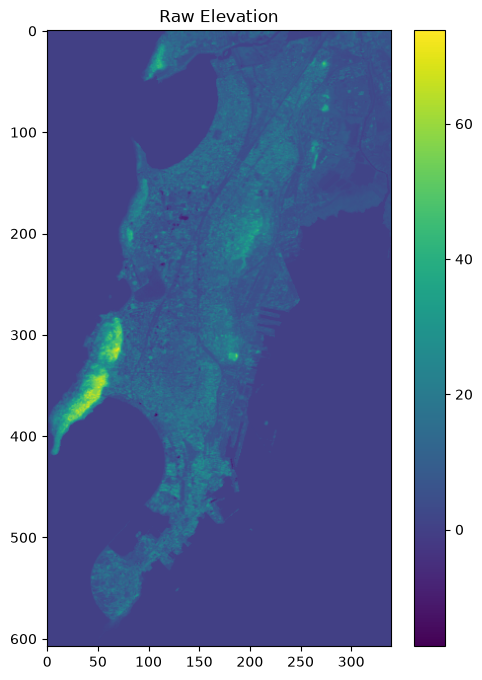

dict_keys(['elevation', 'slope', 'aspect', 'hillshade'])

In [39]:
import numpy as np
from scipy.ndimage import sobel

# Elevation
elevation = terrain["data"].squeeze()

import numpy as np

mask = np.isnan(elevation.values)

print("Total NaNs:", mask.sum())

# Count NaNs in each row
nan_per_row = mask.sum(axis=1)

print(nan_per_row[:20])      # first rows
print(nan_per_row[-20:])     # last rows

# First completely empty row
empty_rows = np.where(nan_per_row == elevation.shape[1])[0]

print(empty_rows[:20])

import matplotlib.pyplot as plt
import numpy as np

print("Shape:", elevation.shape)
print("NaN count:", np.isnan(elevation.values).sum())
print("Min:", np.nanmin(elevation.values))
print("Max:", np.nanmax(elevation.values))

plt.figure(figsize=(6, 8))
plt.imshow(elevation.values, origin="upper")
plt.colorbar()
plt.title("Raw Elevation")
plt.show()

# Calculate gradients
dz_dx = sobel(elevation.values, axis=1) / 8.0
dz_dy = sobel(elevation.values, axis=0) / 8.0

# Slope (degrees)
slope = np.degrees(
    np.arctan(
        np.sqrt(dz_dx**2 + dz_dy**2)
    )
)

# Aspect (degrees)
aspect = np.degrees(
    np.arctan2(
        -dz_dx,
        dz_dy
    )
)

aspect = np.where(
    aspect < 0,
    aspect + 360,
    aspect
)

# Hillshade
azimuth = np.radians(315)
altitude = np.radians(45)

slope_rad = np.radians(slope)
aspect_rad = np.radians(aspect)

hillshade = 255 * (

    np.cos(altitude) * np.cos(slope_rad)

    +

    np.sin(altitude)
    * np.sin(slope_rad)
    * np.cos(azimuth - aspect_rad)

)

hillshade = np.clip(hillshade, 0, 255)

import xarray as xr

terrain_layers = {

    "elevation": elevation,

    "slope": xr.DataArray(
        slope,
        coords=elevation.coords,
        dims=elevation.dims,
        attrs={"units": "degrees"}
    ),

    "aspect": xr.DataArray(
        aspect,
        coords=elevation.coords,
        dims=elevation.dims,
        attrs={"units": "degrees"}
    ),

    "hillshade": xr.DataArray(
        hillshade,
        coords=elevation.coords,
        dims=elevation.dims,
        attrs={"units": "0-255"}
    )

}

terrain_layers.keys()

# Terrain Product

## Purpose

Create and populate the standardized Terrain Product.

The Terrain Product summarizes the terrain dataset, derived terrain layers, and processing metadata generated by the Terrain Engine.

It serves as the primary output of the Terrain Engine and provides terrain information for downstream Earth Intelligence modules.

In [40]:
from datetime import datetime

terrain_product = {

    "metadata": {

        "engine": "Terrain Engine",

        "version": "1.0",

        "created_at": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )

    },

    "dataset": {

        "id": selected_dataset["id"],

        "name": selected_dataset["name"],

        "provider": selected_dataset["provider"],

        "category": selected_dataset["category"],

        "stac_collection": selected_dataset["stac_collection"]

    },

    "terrain": {

        "layers": list(terrain_layers.keys()),

        "crs": str(elevation.rio.crs),

        "width": elevation.sizes["longitude"],

        "height": elevation.sizes["latitude"],

        "resolution": {

            "x": float(
                abs(
                    elevation.longitude[1]
                    - elevation.longitude[0]
                )
            ),

            "y": float(
                abs(
                    elevation.latitude[1]
                    - elevation.latitude[0]
                )
            )

        }

    },

    "processing": {

        "terrain_layers": list(
            terrain_layers.keys()
        )

    }

}

terrain_product

{'metadata': {'engine': 'Terrain Engine',
  'version': '1.0',
  'created_at': '2026-07-20 17:33:48'},
 'dataset': {'id': 'copernicus_dem',
  'name': 'Copernicus DEM',
  'provider': 'Copernicus',
  'category': 'Terrain',
  'stac_collection': 'cop-dem-glo-30'},
 'terrain': {'layers': ['elevation', 'slope', 'aspect', 'hillshade'],
  'crs': 'EPSG:4326',
  'width': 340,
  'height': 608,
  'resolution': {'x': 0.0002777777777822621, 'y': 0.0002777777777787094}},
 'processing': {'terrain_layers': ['elevation',
   'slope',
   'aspect',
   'hillshade']}}

# Export Terrain Product

## Purpose

Export the outputs generated by the Terrain Engine.

The Terrain Product metadata is exported as a JSON file.

The terrain layers are exported as a NetCDF dataset for downstream Earth Intelligence modules.

In [41]:
from pathlib import Path
import json
import xarray as xr

OUTPUT_DIR = Path(
    "/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Earth-Intelligence-System/data/outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Export Terrain Product
terrain_product_file = OUTPUT_DIR / "terrain_product.json"

with open(terrain_product_file, "w", encoding="utf-8") as file:
    json.dump(
        terrain_product,
        file,
        indent=4,
        default=str
    )

# Combine terrain layers into one Dataset
terrain_dataset = xr.Dataset({

    "elevation": terrain_layers["elevation"],

    "slope": terrain_layers["slope"],

    "aspect": terrain_layers["aspect"],

    "hillshade": terrain_layers["hillshade"]

})

# Export terrain layers
terrain_dataset_file = OUTPUT_DIR / "terrain_layers.nc"

terrain_dataset.to_netcdf(
    terrain_dataset_file
)

print(f"Terrain Product : {terrain_product_file.name}")
print(f"Terrain Layers  : {terrain_dataset_file.name}")

Terrain Product : terrain_product.json
Terrain Layers  : terrain_layers.nc


# Terrain Engine Summary

## Purpose

Summarize the outputs generated by the Terrain Engine.

This summary confirms that the Digital Elevation Model was successfully processed into standardized terrain layers for downstream analysis.

In [42]:
summary = {

    "Dataset": terrain_product["dataset"]["name"],

    "Terrain Layers": ", ".join(
        terrain_product["terrain"]["layers"]
    ),

    "Coordinate System": terrain_product["terrain"]["crs"],

    "Raster Size": (
        f"{terrain_product['terrain']['width']} × "
        f"{terrain_product['terrain']['height']}"
    )

}

for key, value in summary.items():
    print(f"{key:<20}: {value}")

Dataset             : Copernicus DEM
Terrain Layers      : elevation, slope, aspect, hillshade
Coordinate System   : EPSG:4326
Raster Size         : 340 × 608
